# 🧠 TechMind
# Organização Inteligente de Conhecimento Técnico

## O Projeto

Criar uma solução (MVP funcional) que permita o enriquecimento e a organização inteligente de conteúdo técnico, facilitando sua classificação, consulta e reutilização. 

A solução deve utilizar técnicas de Ciência de Dados e integração com uma API

## Objetivo

• Criar e treinar modelos de classificação por categoria técnica

• Avaliar modelos e disponibilizar o de melhor performance para ser consumido via API

• Extração de palavras-chave

• Serialização do modelo e geração de .pkl

## Bibliotecas

In [1]:
# Importa as Bibliotecas

# Manipulação de dados
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

## Obtendo Dados

In [2]:
# Carregando dados 
df = pd.read_csv('../dados/base_techmind.csv')
df.sample(5)

,texto,categoria
1213,series rikmakershub build log executive summar...,Frontend
146,panda backbone datum processing python . clean...,DataScience
599,follow blueprint early - s cyber expert india ...,Security
142,claude mythos flaw claim signal market shift a...,Security
1315,cyberpunk interface look game film ship actual...,Frontend


### Conhecendo Dados e Estruturas

In [3]:
# Conhecendo dados e estrutura
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1564 entries, 0 to 1563
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   texto      1564 non-null   str  
 1   categoria  1564 non-null   str  
dtypes: str(2)
memory usage: 6.2 MB


In [4]:
# Conferindo dados
df['categoria'].value_counts()

categoria
Backend        319
Security       301
Database       268
Frontend       252
Cloud          240
DataScience    184
Name: count, dtype: int64

## Pré Modelagem 

In [5]:
# Base para modelagem
df_model = df.copy()
df_model.shape

(1564, 2)

### Separação de Dados

Divisão da base em conjuntos de treino (80%) e teste (20%), utilizando `stratify=categoria` para preservar a proporção de cada categoria em ambos os conjuntos. Isso é importante devido o desbalanceamento entre classes (ex: DataScience possui bem menos registros que Backend).

In [6]:
# Split treino/teste (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    df_model['texto'],
    df_model['categoria'],
    test_size=0.2,
    random_state=42,
    stratify=df_model['categoria']
)

print(X_train.shape, X_test.shape)

(1251,) (313,)


In [7]:
# Validando proporção das categorias para treino (stratify)
print(y_train.value_counts(normalize=True))

# Validando proporção das categorias para teste (stratify)
print(y_test.value_counts(normalize=True))

categoria
Backend        0.203837
Security       0.192646
Database       0.171063
Frontend       0.161471
Cloud          0.153477
DataScience    0.117506
Name: proportion, dtype: float64
categoria
Backend        0.204473
Security       0.191693
Database       0.172524
Frontend       0.159744
Cloud          0.153355
DataScience    0.118211
Name: proportion, dtype: float64


Conferência das proporções de cada categoria em `y_train` e `y_test` para garantir que o `stratify` manteve a distribuição original da base. As proporções ficaram praticamente idênticas entre os dois conjuntos, confirmando que o split foi feito corretamente.

### TF-IDF (vetorização)

Transformação dos textos em vetores numéricos usando TF-IDF (Term Frequency - Inverse Document Frequency), que atribui peso maior a termos relevantes e discriminativos para cada categoria, e peso menor a termos muito comuns.

O vetorizador é ajustado (`fit_transform`) apenas nos dados de treino, e aplicado (`transform`) nos dados de teste, evitando vazamento de informação do teste para o treino.

In [8]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(1251, 5000) (313, 5000)


Parâmetros escolhidos:
- `max_features=5000`: limita o vocabulário aos 5000 termos mais relevantes, evitando ruído de palavras raras
- `ngram_range=(1, 2)`: considera palavras isoladas e pares de palavras, capturando um pouco mais de contexto

*(stopwords não são reaplicadas aqui pois já foram removidas na limpeza via spaCy)*

## Modelo Logistic Regression

### Modelagem - Logistic Regression (baseline)

#### Criação do Modelo

In [9]:
# Cria modelo de classificação 
modelo_lr = LogisticRegression(
    max_iter=1000, 
    random_state=42
)

#### Validação Cruzada (Cross-Validation)

Antes de avaliar o modelo no conjunto de teste, aplicamos validação cruzada (5-fold) nos dados de treino para verificar se o desempenho do modelo é consistente, evitando conclusões baseadas em um único split.

Utilizamos `f1_macro` como métrica, por ponderar igualmente todas as categorias, mais adequada que a acurácia dado o desbalanceamento da base.

In [10]:
scores_lr = cross_val_score(
    modelo_lr, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)

print(f"F1 macro: {scores_lr.mean():.4f} (+/- {scores_lr.std():.4f})")

F1 macro: 0.7953 (+/- 0.0149)


A validação cruzada apresentou F1 macro médio de 0.7953, com desvio padrão de 0.0149 entre os 5 folds. O desvio baixo indica que o desempenho do modelo Logistic Regression é consistente independente de quais dados caem em cada fold, reforçando a confiabilidade do resultado antes de avaliarmos o modelo no conjunto de teste.

#### Treinamento do modelo

In [11]:
# Treino do modelo Logistic Regression
modelo_lr.fit(
    X_train_tfidf,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### Avaliação do Modelo  - Logistic Regression (baseline)

Avaliação do desempenho do modelo nos dados de teste, utilizando métricas por categoria (precision, recall, F1-score), já que a base possui desbalanceamento entre classes o accuracy geral sozinho não seria suficiente para avaliar corretamente o modelo.

In [12]:
# Predição nos dados de teste
y_pred_lr = modelo_lr.predict(X_test_tfidf)

In [13]:
# Métricas de avaliação
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

     Backend       0.73      0.75      0.74        64
       Cloud       0.85      0.81      0.83        48
 DataScience       0.89      0.68      0.77        37
    Database       0.91      0.91      0.91        54
    Frontend       0.73      0.72      0.73        50
    Security       0.81      0.95      0.88        60

    accuracy                           0.81       313
   macro avg       0.82      0.80      0.81       313
weighted avg       0.81      0.81      0.81       313



O modelo de Regressão Logística obteve 81% de acurácia no conjunto de teste, resultado consistente com o F1 macro de 0.7918 estimado na validação cruzada. Como a base apresenta desbalanceamento entre categorias, a análise por classe (precision, recall e F1-score) é mais informativa que a acurácia geral isoladamente:

* Melhor desempenho (F1 ≥ 0.90): Database (F1 0.91)
* Desempenho intermediário (F1 ≥ 0.80): Security (F1 0.88) e Cloud (F1 0.83)
* Menor desempenho (F1 < 0.80): DataScience (F1 0.77), Backend (F1 0.74) e Frontend (F1 0.73)

DataScience, mesmo sendo a categoria com menos registros de treino, apresentou recall de 0.68 e F1 de 0.77, um bom resultado considerando o desbalanceamento da base.

As métricas macro avg (média simples entre categorias) e weighted avg (média ponderada pelo número de exemplos de cada categoria) ficaram iguais (0.81), reforçando que o desempenho está equilibrado entre as categorias, apesar do desbalanceamento da base.

##### Matriz de Confusão

Visualização de quais categorias o modelo mais confunde entre si, complementando a análise de precision/recall por classe.

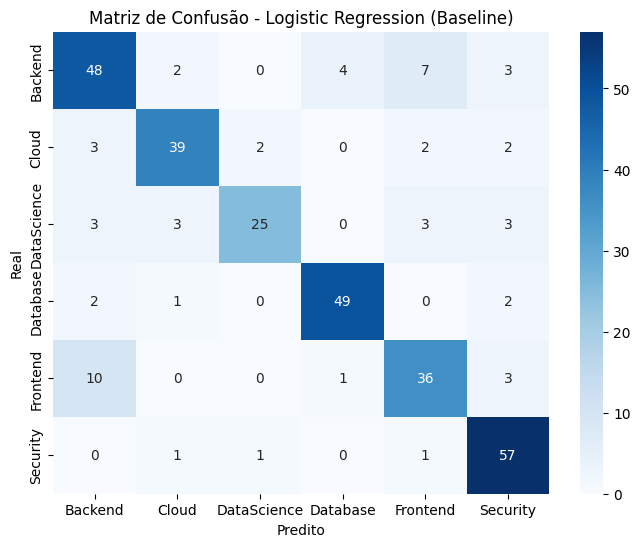

In [14]:
cm = confusion_matrix(y_test, y_pred_lr, labels=modelo_lr.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_lr.classes_, yticklabels=modelo_lr.classes_)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Logistic Regression (Baseline)')
plt.show()

A matriz de confusão confirma o padrão observado nas métricas: 

* A confusão está espalhada entre as categorias, sem um padrão dominante. 
* A maior concentração de erros ocorre entre Frontend e Backend (10 casos de Frontend classificados como Backend), sugerindo sobreposição de vocabulário técnico entre essas categorias.
* Security e Cloud, por outro lado, apresentam baixíssima confusão cruzada, confirmando seu bom desempenho.

O modelo baseline de Regressão Logística obteve um desempenho consistente (81% de acurácia, F1 macro 0.81), sem nenhuma categoria com fragilidade evidente. 

Ainda assim, testaremos o modelo com o parâmetro class_weight='balanced', que ajusta o peso das classes durante o treino de forma inversamente proporcional à frequência de cada categoria, para verificar se esse ajuste traz algum ganho adicional em categorias com menos registros, como DataScience.

### Modelagem - Logistic Regression (com class_weight='balanced')

#### Criando Modelo 

In [15]:
# Criando modelo 
modelo_lr_balanced = LogisticRegression(max_iter=1000, 
                                        random_state=42, 
                                        class_weight='balanced')

#### Validação Cruzada (Cross-Validation) - Modelo com class_weight='balanced'

In [16]:
# Cross-validation
scores_lr_balanced = cross_val_score(
    modelo_lr_balanced, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)

print(f"F1 macro: {scores_lr_balanced.mean():.4f} (+/- {scores_lr_balanced.std():.4f})")

F1 macro: 0.8074 (+/- 0.0174)


A validação cruzada do modelo com class_weight='balanced' apresentou F1 macro médio de 0.8074, com desvio padrão de 0.0174 entre os 5 folds. Comparado ao baseline (F1 macro 0.7953, desvio 0.0149), o modelo balanced teve desempenho médio superior e leve redução na variação entre os folds, o que reforça a decisão de avançar com essa configuração para a avaliação final no conjunto de teste.

#### Treinamento do modelo

In [17]:
# Treino
modelo_lr_balanced.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Comparação - Avaliação dos Modelos Logistic Regression

In [18]:
# Predição Modelo com balanced
y_pred_lr_balanced = modelo_lr_balanced.predict(X_test_tfidf)

In [19]:
# Métricas de avaliação dos modelos (sem e com class_weight='balanced') 

# Gerando os relatórios como DataFrame
report_baseline = pd.DataFrame(classification_report(y_test, y_pred_lr, output_dict=True)).transpose()
report_balanced = pd.DataFrame(classification_report(y_test, y_pred_lr_balanced, output_dict=True)).transpose()

# Comparando performance dos dois modelos
comparacao = pd.concat([report_baseline, report_balanced], axis=1, keys=['Baseline', 'Balanced'])
comparacao.round(2)

Baseline                          Balanced                  \
             precision recall f1-score support precision recall f1-score   
Backend           0.73   0.75     0.74   64.00      0.80   0.67     0.73   
Cloud             0.85   0.81     0.83   48.00      0.84   0.85     0.85   
DataScience       0.89   0.68     0.77   37.00      0.70   0.70     0.70   
Database          0.91   0.91     0.91   54.00      0.88   0.91     0.89   
Frontend          0.73   0.72     0.73   50.00      0.74   0.78     0.76   
Security          0.81   0.95     0.88   60.00      0.84   0.90     0.87   
accuracy          0.81   0.81     0.81    0.81      0.81   0.81     0.81   
macro avg         0.82   0.80     0.81  313.00      0.80   0.80     0.80   
weighted avg      0.81   0.81     0.81  313.00      0.80   0.81     0.80   

                      
             support  
Backend        64.00  
Cloud          48.00  
DataScience    37.00  
Database       54.00  
Frontend       50.00  
Security       60.00  
accuracy        0.81  
macro avg     313.00  
weighted avg  313.00

A tabela comparativa mostra que os dois modelos tiveram a mesma acurácia (0.81). No macro avg, o F1-score foi levemente menor no balanced (0.80) em relação ao baseline (0.81), embora o recall médio tenha sido um pouco maior (0.81 contra 0.80) e a precision média menor (0.80 contra 0.82).

Em DataScience, o balanced trouxe um trade-off: o recall subiu de 0.68 para 0.73, mas a precision caiu de 0.89 para 0.71, resultando em um F1-score menor (de 0.77 para 0.72).

Em Backend, aconteceu o oposto: a precision subiu de 0.72 para 0.80, enquanto o recall caiu de 0.75 para 0.67, mantendo o F1-score praticamente igual (0.73 nos dois modelos).

Nas demais categorias, as variações foram pequenas: Cloud (F1 0.84 para 0.85) e Frontend (F1 0.73 para 0.76) melhoraram levemente, enquanto Database (F1 0.91 para 0.89) e Security (F1 0.88 para 0.87) caíram um pouco.

No geral, o balanceamento não trouxe ganho evidente nessa base. 

#### Comparação - Matriz de Confusão

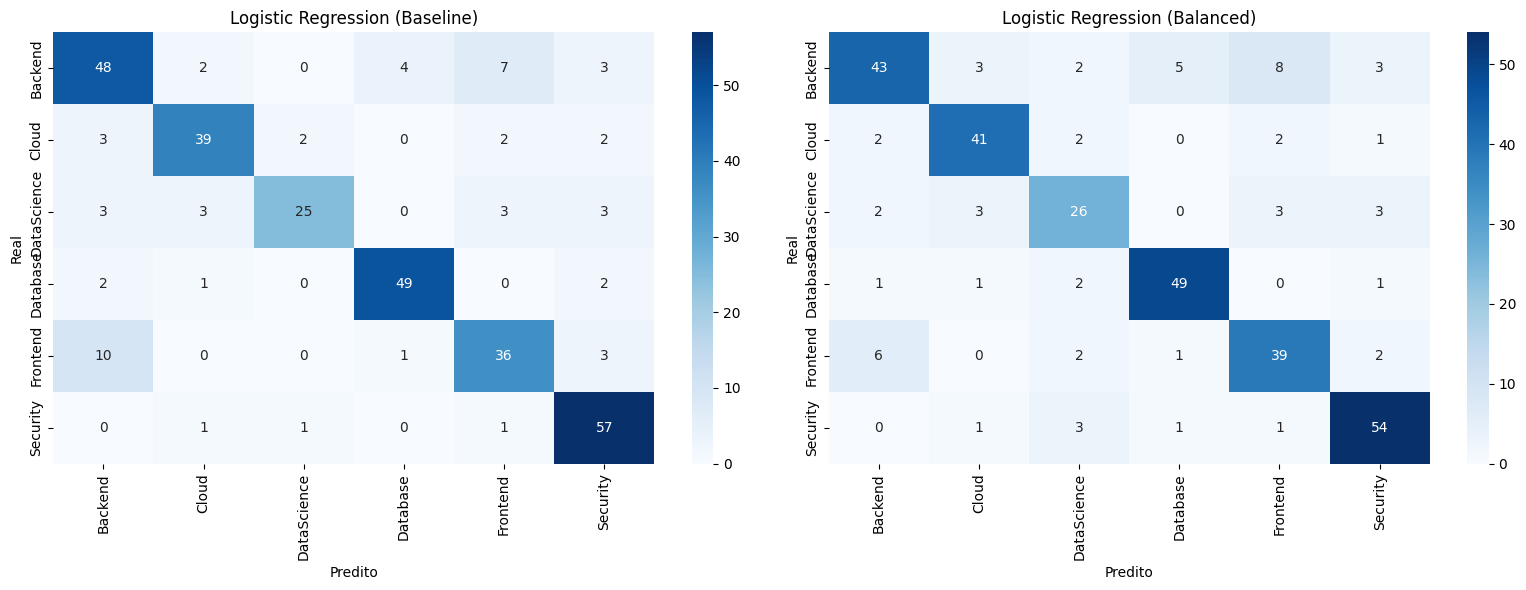

In [20]:
# Comparando as matrizes de confusão 
cm = confusion_matrix(y_test, y_pred_lr, labels=modelo_lr.classes_)
cm_balanced = confusion_matrix(y_test, y_pred_lr_balanced, labels=modelo_lr_balanced.classes_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_lr.classes_, yticklabels=modelo_lr.classes_,
            ax=axes[0])
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')
axes[0].set_title('Logistic Regression (Baseline)')

sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_lr_balanced.classes_, yticklabels=modelo_lr_balanced.classes_,
            ax=axes[1])
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_title('Logistic Regression (Balanced)')

plt.tight_layout()
plt.show()

Comparando as duas matrizes, DataScience teve mais acertos no balanced (27 contra 25 no baseline), e a confusão com Backend caiu de 4 para 2 casos.

Em compensação, Backend teve menos acertos no balanced (43 contra 48 no baseline), recebendo mais confusão vinda de Frontend (8 casos, contra 7 no baseline). A confusão entre DataScience e Backend, por outro lado, diminuiu nos dois sentidos.

Cloud e Security permaneceram com padrão parecido nos dois modelos, com pequenas variações pontuais.

Conclusão - Modelo Logistic Regression

Comparando os dois modelos, o balanceamento não trouxe ganho real nessa base já mais equilibrada após a limpeza. 

Em DataScience, o ganho de recall veio acompanhado de uma queda maior na precision, reduzindo o F1 da categoria. 

Em Backend, o ganho de precision veio acompanhado de uma queda equivalente no recall, mantendo o F1 praticamente igual. 

No resultado geral, essas trocas não se traduziram em melhora. O F1 macro do balanced ficou levemente abaixo do baseline (0.80 contra 0.81). 

Considerando essas informações, o modelo baseline será considerado o modelo final da Regressão Logística.

## Modelo Naive Bayes

### Modelagem - Naive Bayes (baseline)

#### Criação do Modelo

In [21]:
# Cria modelo de classificação Naive Bayes (baseline)
modelo_nb = MultinomialNB(
    alpha=1.0, 
    fit_prior=True)

#### Validação Cruzada (Cross-Validation)

Antes de avaliar o modelo no conjunto de teste, aplicamos validação cruzada (5-fold) nos dados de treino para verificar se o desempenho do modelo é consistente, evitando conclusões baseadas em um único split.

Utilizamos `f1_macro` como métrica, por ponderar igualmente todas as categorias, mais adequada que a acurácia dado o desbalanceamento da base.

In [22]:
# Cross-validation Naive Bayes (baseline)
scores_nb = cross_val_score(
    modelo_nb, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)

print(f"F1 macro: {scores_nb.mean():.4f} (+/- {scores_nb.std():.4f})")

F1 macro: 0.7575 (+/- 0.0382)


A validação cruzada apresentou um F1 macro médio de 0,7575, com desvio padrão de 0,0382 entre os 5 folds. Essa variação contida indica estabilidade aceitável no desempenho do Naive Bayes (baseline), demonstrando que o modelo mantém um comportamento consistente independentemente da divisão dos dados de treino.

#### Treinamento do modelo

In [23]:
# Treino do modelo SVM (baseline)
modelo_nb.fit(
    X_train_tfidf,
    y_train
)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


#### Avaliação do Modelo  - Naive Bayes (baseline)

Avaliação do desempenho do modelo nos dados de teste, utilizando métricas por categoria (precision, recall, F1-score), já que a base possui desbalanceamento entre classes o accuracy geral sozinho não seria suficiente para avaliar corretamente o modelo.

In [24]:
# Predição nos dados de teste Naive Bayes (baseline)
y_pred_nb = modelo_nb.predict(X_test_tfidf)

In [25]:
# Métricas de avaliação SVM (baseline)
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

     Backend       0.58      0.77      0.66        64
       Cloud       0.92      0.75      0.83        48
 DataScience       0.89      0.43      0.58        37
    Database       0.88      0.93      0.90        54
    Frontend       0.70      0.62      0.66        50
    Security       0.83      0.97      0.89        60

    accuracy                           0.77       313
   macro avg       0.80      0.74      0.75       313
weighted avg       0.79      0.77      0.76       313



O modelo Naive Bayes (baseline) obteve 77% de acurácia no conjunto de teste, resultado consistente com o F1 macro estimado na validação cruzada. Como a base apresenta desbalanceamento entre categorias, a análise detalhada por classe (precision, recall e f1-score) oferece uma leitura mais precisa do desempenho:

* Melhor desempenho (F1 ≥ 0.90): `Database` (F1 0.90)
* Desempenho intermediário (F1 ≥ 0.80): `Cloud` (F1 0.83) e`Security` (F1 0.89) 
* Menor desempenho (F1 < 0.70): `Frontend` (F1 0.66), e `Backend` (F1 0.66), `DataScience` (F1 0.58)

A categoria `DataScience`, por possuir o menor número de registros de teste (support = 37), apresentou o menor recall do modelo (0.43) e um (F1 0.58), evidenciando maior dificuldade de captura da classe.

As métricas consolidadas apresentaram macro avg de 0.75 e weighted avg de 0.76 para $F1\text{-score}$ (com precisões médias de 0.80 e 0.79, respectivamente), refletindo o impacto das categorias mais desbalanceadas no resultado geral do modelo.

##### Matriz de Confusão

Visualização de quais categorias o modelo mais confunde entre si, complementando a análise de precision/recall por classe.

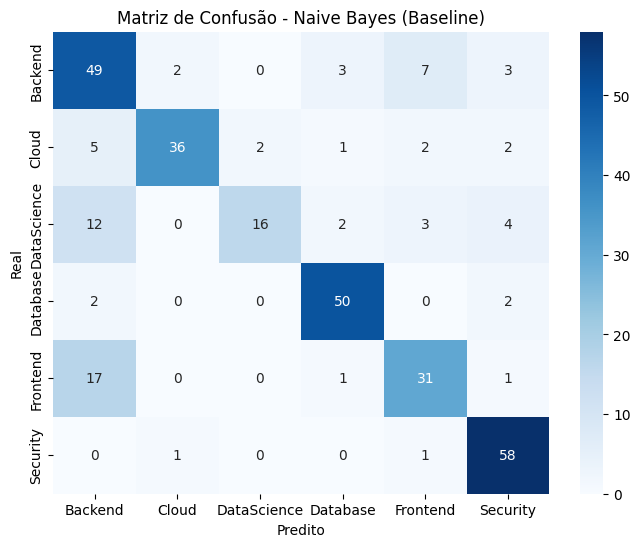

In [26]:
# Matriz Confusão Naive Bayes (baseline)
cm = confusion_matrix(y_test, y_pred_nb, labels=modelo_nb.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_nb.classes_, yticklabels=modelo_nb.classes_)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Naive Bayes (Baseline)')
plt.show()

A matriz de confusão confirma o padrão observado nas métricas: 

* A maior confusão pontual ocorre no `Frontend:` 17 textos da categoria `Frontend` foram incorretamente classificados como `Backend`, o que evidencia uma forte sobreposição de vocabulário técnico e atrai falsos positivos para a classe de desenvolvimento. 

* `Backend` é a classe com maior dispersão de erros: Além de receber falsos positivos de outras categorias, seus textos reais foram pulverizados entre `Frontend` (7 casos), `Security` (3 casos), `Database` (3 casos) e `Cloud` (2 casos).

* Alta taxa de confusão em `DataScience:` Dos 37 registros reais de DataScience, 12 foram classificados erroneamente como Backend, explicando o baixo recall (0.43) observado no relatório de classificação.

* `Security`, `Database` e `Cloud` apresentam excelente separação: A classe `Security` obteve o maior número de acertos absolutos (58), seguida por `Database` (50) e `Cloud` (36), todas apresentando baixíssima confusão cruzada com as demais áreas.

### Modelagem - Naive Bayes (Balanced)

#### Criando Modelo 

In [27]:
# Cria modelo de classificação Naive Bayes (balanced)
modelo_nb_balanced = MultinomialNB(
    alpha=0.1,
    fit_prior=False
)

#### Validação Cruzada (Cross-Validation) - Modelo (Balanced)

In [28]:
# Cross-validation Nayve Bayes (balanced)
scores_nb_balanced = cross_val_score(
    modelo_nb_balanced, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)

print(f"F1 macro: {scores_nb_balanced.mean():.4f} (+/- {scores_nb_balanced.std():.4f})")

F1 macro: 0.7935 (+/- 0.0167)


A validação cruzada do modelo com fit_prior=False apresentou F1 macro médio de 0.7935, com desvio padrão de 0.0167 entre os 5 folds. Comparado ao baseline (F1 macro 0.7575, desvio padrão 0.0382), o modelo balanced teve desempenho médio superior e  redução na variação entre os folds, o que reforça a decisão de avançar com essa configuração para a avaliação final no conjunto de teste.

#### Treinamento do modelo

In [29]:
# Treino do modelo SVM (balanced)
modelo_nb_balanced.fit(
    X_train_tfidf,
    y_train
)

,alpha,0.1
,force_alpha,True
,fit_prior,False
,class_prior,None


### Comparação - Avaliação dos Modelos Naive Bayes

In [30]:
# Predição Modelo Naive Bayes (balanced)
y_pred_nb_balanced = modelo_nb_balanced.predict(X_test_tfidf)

In [31]:
# Métricas de avaliação dos modelos (sem e com class_weight='balanced') 

# Gerando os relatórios como DataFrame
report_baseline = pd.DataFrame(classification_report(y_test, y_pred_nb, output_dict=True)).transpose()
report_balanced = pd.DataFrame(classification_report(y_test, y_pred_nb_balanced, output_dict=True)).transpose()

# Comparando performance dos dois modelos
comparacao = pd.concat([report_baseline, report_balanced], axis=1, keys=['Baseline', 'Balanced'])
comparacao.round(2)

Baseline                          Balanced                  \
             precision recall f1-score support precision recall f1-score   
Backend           0.58   0.77     0.66   64.00      0.75   0.70     0.73   
Cloud             0.92   0.75     0.83   48.00      0.83   0.81     0.82   
DataScience       0.89   0.43     0.58   37.00      0.73   0.73     0.73   
Database          0.88   0.93     0.90   54.00      0.89   0.91     0.90   
Frontend          0.70   0.62     0.66   50.00      0.73   0.74     0.73   
Security          0.83   0.97     0.89   60.00      0.86   0.90     0.88   
accuracy          0.77   0.77     0.77    0.77      0.80   0.80     0.80   
macro avg         0.80   0.74     0.75  313.00      0.80   0.80     0.80   
weighted avg      0.79   0.77     0.76  313.00      0.80   0.80     0.80   

                      
             support  
Backend         64.0  
Cloud           48.0  
DataScience     37.0  
Database        54.0  
Frontend        50.0  
Security        60.0  
accuracy         0.8  
macro avg      313.0  
weighted avg   313.0

A tabela comparativa demonstra a evolução do modelo com o ajuste de classe (Balanced): a acurácia global subiu de 0,77 para 0,80, acompanhada pelo aumento do F1 macro (de 0,75 para 0,80) e da média ponderada (weighted avg de 0,76 para 0,80).

Em `DataScience:` A abordagem Balanced corrigiu o gargalo do modelo: o recall deu um salto de 0,43 para 0,73, elevando o $F1\text{-score}$ da classe de 0,58 para 0,73, apesar da redução na precisão ($0,89 \to 0,73$).

Em `Backend:` A precisão subiu de 0,58 para 0,75 e o $F1\text{-score}$ evoluiu de 0,66 para 0,73, com uma leve redução no recall ($0,77 \to 0,70$).

Em `Frontend:` Houve um equilíbrio geral, aumentando o recall de 0,62 para 0,74 e elevando o $F1\text{-score}$ de 0,66 para 0,73.

Nas demais categorias: `Database` manteve seu alto desempenho estável ($F1 = 0,90$), enquanto `Security` e `Cloud` registraram reduções marginais de 1 ponto percentual no $F1\text{-score}$ ($0,89 \to 0,88$ e $0,83 \to 0,82$, respectivamente).

A abordagem Balanced foi altamente eficaz para resolver a assimetria das classes menores (especialmente `DataScience`), promovendo um ganho real de desempenho e maior equilíbrio de classificação entre todas as categorias.

#### Comparação - Matriz de Confusão

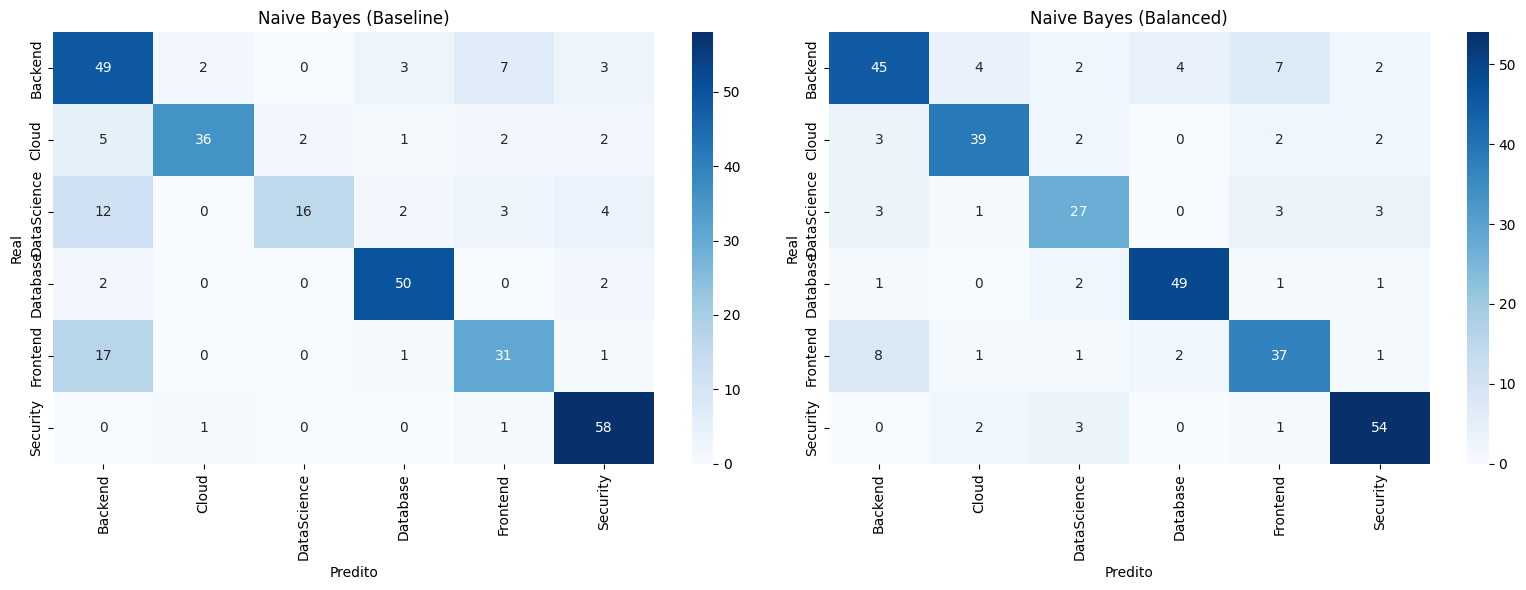

In [32]:
# Comparando as matrizes de confusão Nayve Bayes (baseline) vs. (balanced)
cm = confusion_matrix(y_test, y_pred_nb, labels=modelo_nb.classes_)
cm_balanced = confusion_matrix(y_test, y_pred_nb_balanced, labels=modelo_nb_balanced.classes_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_nb.classes_, yticklabels=modelo_nb.classes_,
            ax=axes[0])
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')
axes[0].set_title('Naive Bayes (Baseline)')

sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_nb_balanced.classes_, yticklabels=modelo_nb_balanced.classes_,
            ax=axes[1])
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_title('Naive Bayes (Balanced)')

plt.tight_layout()
plt.show()

A comparação entre as duas matrizes evidencia o impacto direto do ajuste de classe (fit_prior=False) no modelo Naive Bayes, eliminando a tendência do modelo em favorecer a categoria com maior número de registros no treino.

Destaques da Comparação  

* Recuperação Expressiva de DataScience:

  * No `Baseline`, a classe sofria forte apaziguamento: apenas 16 acertos reais, enquanto 12 chamados foram erroneamente previstos como `Backend`.

  * No `Balanced`, os acertos dispararam para 27, reduzindo a confusão com Backend para apenas 3 casos.

* Mitigação do Viés em `Frontend:`

  * No Baseline, 17 chamados de `Frontend` eram classificados incorretamente como `Backend`, limitando os acertos em 31.

  *  No Balanced, essa falsa atração caiu para menos da metade (8 casos), elevando os acertos corretos de `Frontend` para 37.

* Estabilidade nas Demais Categorias (`Database`, `Security` e `Cloud`):

  * `Cloud:` Teve leve ganho, subindo de 36 para 39 acertos.

  * `Database` e `Security:` Apresentaram reduções marginais inevitáveis na diagonal principal (Database: 50 $\to$ 49; Security: 58 $\to$ 54), mas mantiveram baixíssima taxa de erro cruzado.

Conclusão - Modelo Naive Bayes

A matriz do modelo Balanced comprova que a readequação das probabilidades a priori corrigiu o gargalo do Naive Bayes Baseline. O modelo deixou de acumular falsos positivos na classe Backend, redistribuindo a capacidade preditiva de forma mais justa e promovendo um salto de assertividade nas categorias que antes eram penalizadas (`DataScience` e `Frontend`).

## Modelo SVM 

### Modelagem - SVM (baseline)

#### Criação do Modelo

In [33]:
# Cria modelo de classificação SVM (baseline)
modelo_svm = SVC(
    kernel='linear', 
    probability=True,
    random_state=42
)

#### Validação Cruzada (Cross-Validation)

Antes de avaliar o modelo no conjunto de teste, aplicamos validação cruzada (5-fold) nos dados de treino para verificar se o desempenho do modelo é consistente, evitando conclusões baseadas em um único split.

Utilizamos `f1_macro` como métrica, por ponderar igualmente todas as categorias, mais adequada que a acurácia dado o desbalanceamento da base.

In [34]:
# Cross-validation SVM (baseline)
scores_svm = cross_val_score(
    modelo_svm, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)

print(f"F1 macro: {scores_svm.mean():.4f} (+/- {scores_svm.std():.4f})")

F1 macro: 0.8003 (+/- 0.0229)


A validação cruzada apresentou F1 macro médio de 0.8003, com desvio padrão de 0.0229 entre os 5 folds. O desvio baixo indica que o desempenho do modelo SVM (baseline) é consistente independente de quais dados caem em cada fold, reforçando a confiabilidade do resultado antes de avaliarmos o modelo no conjunto de teste.

#### Treinamento do modelo

In [35]:
# Treino do modelo SVM (baseline)
modelo_svm.fit(
    X_train_tfidf,
    y_train
)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


#### Avaliação do Modelo  - SVM (baseline)

Avaliação do desempenho do modelo nos dados de teste, utilizando métricas por categoria (precision, recall, F1-score), já que a base possui desbalanceamento entre classes o accuracy geral sozinho não seria suficiente para avaliar corretamente o modelo.

In [36]:
# Predição nos dados de teste SVM (baseline)
y_pred_svm = modelo_svm.predict(X_test_tfidf)

In [37]:
# Métricas de avaliação SVM (baseline)
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

     Backend       0.68      0.70      0.69        64
       Cloud       0.84      0.77      0.80        48
 DataScience       0.82      0.73      0.77        37
    Database       0.89      0.87      0.88        54
    Frontend       0.74      0.78      0.76        50
    Security       0.86      0.92      0.89        60

    accuracy                           0.80       313
   macro avg       0.80      0.80      0.80       313
weighted avg       0.80      0.80      0.80       313



O modelo SVM (baseline) obteve 80% de acurácia no conjunto de teste, resultado consistente com o F1 macro de 0.7991 estimado na validação cruzada. Como a base apresenta desbalanceamento entre categorias, a análise por classe (precision, recall e F1-score) é mais informativa que a acurácia geral isoladamente:

* Melhor desempenho (F1 < 0.90): `Security` (F1 0.89) e `Database` (F1 0.88)
* Desempenho intermediário (F1 ≥ 0.80): `Cloud` (F1 0.80)
* Menor desempenho (F1 < 0.80): `DataScience` (F1 0.77), `Frontend` (F1 0.76), e `Backend` (F1 0.69)

`DataScience`, mesmo sendo a categoria com menos registros de treino, apresentou recall de 0.73 e F1 de 0.77, um bom resultado considerando o desbalanceamento da base.

As métricas macro avg (média simples entre categorias) e weighted avg (média ponderada pelo número de exemplos de cada categoria) ficaram iguais (0.80), reforçando que o desempenho está equilibrado entre as categorias, apesar do desbalanceamento da base.

##### Matriz de Confusão

Visualização de quais categorias o modelo mais confunde entre si, complementando a análise de precision/recall por classe.

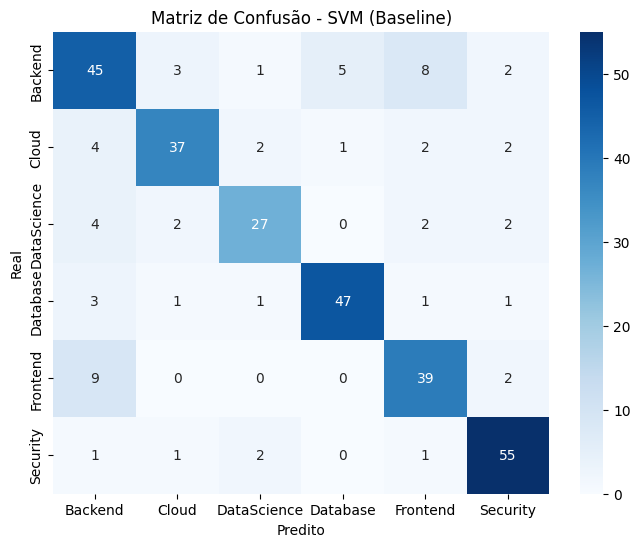

In [38]:
# Matriz Confusão SVM (baseline)
cm = confusion_matrix(y_test, y_pred_svm, labels=modelo_svm.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_svm.classes_, yticklabels=modelo_svm.classes_)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - SVM (Baseline)')
plt.show()

A matriz de confusão confirma o padrão observado nas métricas: 

* A maior confusão pontual ocorre no `Frontend`: 9 textos da categoria `Frontend` foram incorretamente classificados como `Backend`, o que sugere sobreposição de vocabulário técnico entre essas duas áreas. 
* `Backend` é a classe com maior dispersão de erros: Além de receber falsos positivos de outras categorias, seus textos reais foram pulverizados entre `Frontend` (8 casos), `Database` (5 casos), `Cloud` (3 casos), `Security` (2 casos) e `DataScience` (1 caso).
* `Security` e `Cloud` apresentam excelente separação: A classe `Security` obteve o maior número de acertos absolutos (55), apresentando baixíssima confusão cruzada com as demais categorias.

### Modelagem - SVM (com class_weight='balanced')

#### Criando Modelo 

In [39]:
# Cria modelo de classificação SVM (balanced)
modelo_svm_balanced = SVC(
    kernel='linear', 
    class_weight='balanced',
    probability=True,
    random_state=42
)

#### Validação Cruzada (Cross-Validation) - Modelo com class_weight='balanced'

In [40]:
# Cross-validation SVM (balanced)
scores_svm_balanced = cross_val_score(
    modelo_svm_balanced, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)

print(f"F1 macro: {scores_svm_balanced.mean():.4f} (+/- {scores_svm_balanced.std():.4f})")

F1 macro: 0.8034 (+/- 0.0214)


A validação cruzada do modelo com class_weight='balanced' apresentou F1 macro médio de 0.8034, com desvio padrão de 0.0214 entre os 5 folds. Comparado ao baseline (F1 macro 0.8003, desvio padrão 0.0229), o modelo balanced teve desempenho médio superior e  redução na variação entre os folds, o que reforça a decisão de avançar com essa configuração para a avaliação final no conjunto de teste.

#### Treinamento do modelo

In [41]:
# Treino do modelo SVM (balanced)
modelo_svm_balanced.fit(
    X_train_tfidf,
    y_train
)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


### Comparação - Avaliação dos Modelos SVM

In [42]:
# Predição Modelo SVM (balanced)
y_pred_svm_balanced = modelo_svm_balanced.predict(X_test_tfidf)

In [43]:
# Métricas de avaliação dos modelos (sem e com class_weight='balanced') 

# Gerando os relatórios como DataFrame
report_baseline = pd.DataFrame(classification_report(y_test, y_pred_svm, output_dict=True)).transpose()
report_balanced = pd.DataFrame(classification_report(y_test, y_pred_svm_balanced, output_dict=True)).transpose()

# Comparando performance dos dois modelos
comparacao = pd.concat([report_baseline, report_balanced], axis=1, keys=['Baseline', 'Balanced'])
comparacao.round(2)

Baseline                          Balanced                  \
             precision recall f1-score support precision recall f1-score   
Backend           0.68   0.70     0.69    64.0      0.70   0.69     0.69   
Cloud             0.84   0.77     0.80    48.0      0.84   0.79     0.82   
DataScience       0.82   0.73     0.77    37.0      0.78   0.76     0.77   
Database          0.89   0.87     0.88    54.0      0.89   0.87     0.88   
Frontend          0.74   0.78     0.76    50.0      0.72   0.78     0.75   
Security          0.86   0.92     0.89    60.0      0.85   0.88     0.87   
accuracy          0.80   0.80     0.80     0.8      0.80   0.80     0.80   
macro avg         0.80   0.80     0.80   313.0      0.80   0.79     0.80   
weighted avg      0.80   0.80     0.80   313.0      0.80   0.80     0.80   

                      
             support  
Backend         64.0  
Cloud           48.0  
DataScience     37.0  
Database        54.0  
Frontend        50.0  
Security        60.0  
accuracy         0.8  
macro avg      313.0  
weighted avg   313.0

A tabela comparativa mostra que os dois modelos tiveram a mesma acurácia (0.80). No macro avg, o F1-score foi o mesmo (0.80),  o recall médio foi o mesmo (0.80) e a precision média maior (0.81 contra 0.80).

Em `DataScience`, o balanced trouxe: o recall elevou de 0.73 para 0.76,  a precision teve uma leve queda de 0.82 para 0.78, mantendo o mesmo F1-score de 0.77.

Em `Backend`, o balanced trouxe: a precision subiu de 0.68 para 0.70, enquanto o recall caiu de 0.70 para 0.69, mantendo o mesmo F1-score de 0.69.

Nas demais categorias, `Frontend` precision caiu de 0.74 para 0.72, o recall manteve-se o mesmo de 0.78, o F1-score teve uma leve queda 0.76 para 0.75

A abordagem Balanced demonstra ajustes no nível de classe: elevou o Recall de `DataScience` ($0.73 \rightarrow 0.76$) e de `Cloud` ($0.77 \rightarrow 0.79$), além de aumentar ligeiramente a Precisão de `Backend` ($0.68 \rightarrow 0.70$). No entanto, manteve o mesmo desempenho geral do sistema (acurácia global em $0.80$ e F1-macro em $0.80$), sem alterar significativamente a justiça entre as categorias.

#### Comparação - Matriz de Confusão

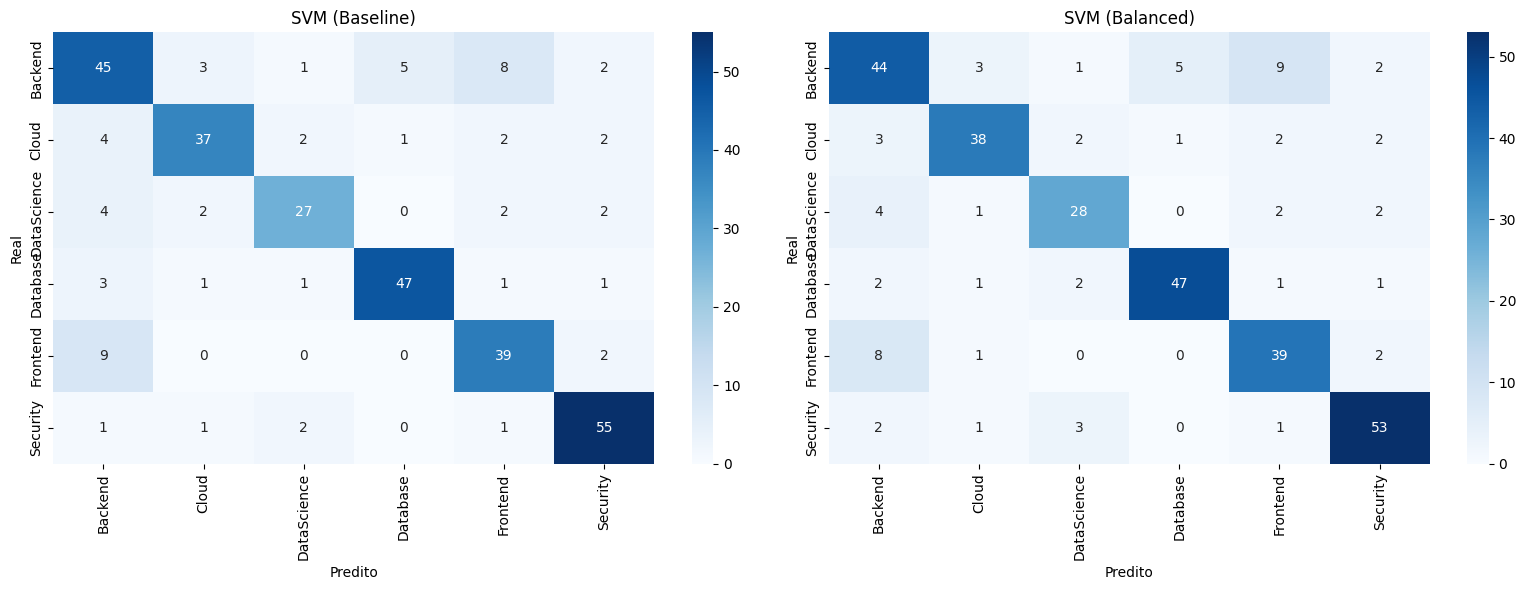

In [44]:
# Comparando as matrizes de confusão SVM (baseline) vs. (balanced)
cm = confusion_matrix(y_test, y_pred_svm, labels=modelo_svm.classes_)
cm_balanced = confusion_matrix(y_test, y_pred_svm_balanced, labels=modelo_svm_balanced.classes_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_svm.classes_, yticklabels=modelo_svm.classes_,
            ax=axes[0])
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')
axes[0].set_title('SVM (Baseline)')

sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_svm_balanced.classes_, yticklabels=modelo_svm_balanced.classes_,
            ax=axes[1])
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_title('SVM (Balanced)')

plt.tight_layout()
plt.show()

A análise das matrizes de confusão indica que ambos os modelos apresentam um comportamento de classificação extremamente próximo na maioria das categorias:

* **Estabilidade nas classes principais:** Em `Database` (47 acertos em ambos) e `Frontend` (39 acertos em ambos), o desempenho foi idêntico.

* **Ganhos pontuais do Balanced:** O modelo Balanced apresentou pequenos ganhos pontuais em `DataScience` (subindo de 27 para 28 acertos) e em `Cloud` (subindo de 37 para 38 acertos).

* **Perdas compensatórias:** Em contrapartida, o uso do reequilíbrio de pesos gerou pequenas perdas compensatórias em `Backend` (de 45 para 44 acertos) e em `Security` (de 55 para 53 acertos, com 3 erros caindo em `DataScience`).

Conclusão - Modelo SVM

Como a base apresenta um desequilíbrio apenas moderado, o modelo SVM (baseline) entrega uma assertividade equivalente na matriz de confusão sem necessitar da alteração artificial de pesos do class_weight='balanced'. Isso preserva a calibração nativa das probabilidades geradas pelo modelo (predict_proba), garantindo que os valores de confiança retornados pela API sejam estatisticamente fiéis à distribuição real dos dados e evitando estimativas superconfiantes em cenários de produção.

Apesar do leve ganho no acerto de classes minoritárias no modelo SVM (balanced), opta-se pela escolha do SVM (baseline) para implementação em produção.

## Comparação dos Modelos 

### Análise Comparativa de Desempenho (Logistic Regression vs. Naive Bayes vs. SVM)

In [46]:
# Métricas de avaliação dos modelos (Logistic Regression vs SVM') 

# Gerando os relatórios como DataFrame
report_lr = pd.DataFrame(classification_report(y_test, y_pred_lr, output_dict=True)).transpose()
report_nb = pd.DataFrame(classification_report(y_test, y_pred_nb, output_dict=True)).transpose()
report_svm = pd.DataFrame(classification_report(y_test, y_pred_svm, output_dict=True)).transpose()

# Comparando performance dos dois modelos
comparacao = pd.concat([report_lr, report_nb, report_svm], axis=1, keys=['Logistic Regression', 'Naive Bayes', 'SVM'])
comparacao.round(2)

Logistic Regression                         Naive Bayes         \
                       precision recall f1-score support   precision recall   
Backend                     0.73   0.75     0.74   64.00        0.58   0.77   
Cloud                       0.85   0.81     0.83   48.00        0.92   0.75   
DataScience                 0.89   0.68     0.77   37.00        0.89   0.43   
Database                    0.91   0.91     0.91   54.00        0.88   0.93   
Frontend                    0.73   0.72     0.73   50.00        0.70   0.62   
Security                    0.81   0.95     0.88   60.00        0.83   0.97   
accuracy                    0.81   0.81     0.81    0.81        0.77   0.77   
macro avg                   0.82   0.80     0.81  313.00        0.80   0.74   
weighted avg                0.81   0.81     0.81  313.00        0.79   0.77   

                                    SVM                          
             f1-score support precision recall f1-score support  
Backend          0.66   64.00      0.68   0.70     0.69    64.0  
Cloud            0.83   48.00      0.84   0.77     0.80    48.0  
DataScience      0.58   37.00      0.82   0.73     0.77    37.0  
Database         0.90   54.00      0.89   0.87     0.88    54.0  
Frontend         0.66   50.00      0.74   0.78     0.76    50.0  
Security         0.89   60.00      0.86   0.92     0.89    60.0  
accuracy         0.77    0.77      0.80   0.80     0.80     0.8  
macro avg        0.75  313.00      0.80   0.80     0.80   313.0  
weighted avg     0.76  313.00      0.80   0.80     0.80   313.0

A avaliação comparativa entre os modelos Logistic Regression, Naive Bayes e SVM revela um desempenho global consistente em todos os algoritmos, com uma leve vantagem geral para a Logistic Regression na base de teste padronizada de 313 amostras (support).

Destaques da Comparação  

**Desempenho Global:** A modelo Logistic Regression obteve o melhor resultado geral, alcançando 81% de acurácia, F1-macro de 0,81 e média ponderada (weighted avg) de 0,81. O modelo SVM ficou ligeiramente atrás com 80% nessas mesmas métricas, enquanto o Naive Bayes apresentou a menor performance global, com acurácia e weighted avg de 77% e F1-macro de 0,75.

**Melhores Categorias:** A classe `Database` alcançou o ponto mais alto do teste com a Logistic Regression (0,91 de F1-score). A categoria `Security` manteve excelente cobertura nos três modelos (F1-score de 0,89 no Naive Bayes e no SVM, e 0,88 na Logistic Regression), com destaque para o recall de 0,97 no Naive Bayes e 0,95 na Logistic Regression.

**Categorias Desafiadoras e Ponto Cego:**

* `Backend` e `Frontend` registraram os menores índices devido à sobreposição semântica. A Logistic Regression liderou em `Backend` (0,74 de F1-score), enquanto o modelo SVM levou vantagem em `Frontend` (0,76 de F1-score).

* `DataScience` revelou um claro gargalo no modelo Naive Bayes, que registrou um recall baixo de 0,43 (F1-score de 0,58). Em contrapartida, o modelo Logistic Regression e o modelo SVM mantiveram bom equilíbrio nessa classe, alcançando F1-scores de 0,77.

Conclusão  
O modelo Logistic Regression apresentou o melhor desempenho consolidado, superando o modelo SVM e o Naive Bayes em acurácia geral e demonstrando maior consistência no tratamento de classes minoritárias sem sacrificar a precisão. Por ser um modelo discriminativo com probabilidades bem calibradas nativamente, é a escolha mais recomendada para integração com limiares de confiança em ambiente de produção.

### Análise da Matriz de Confusão (Logistic Regression vs. Naive Bayes vs. SVM)

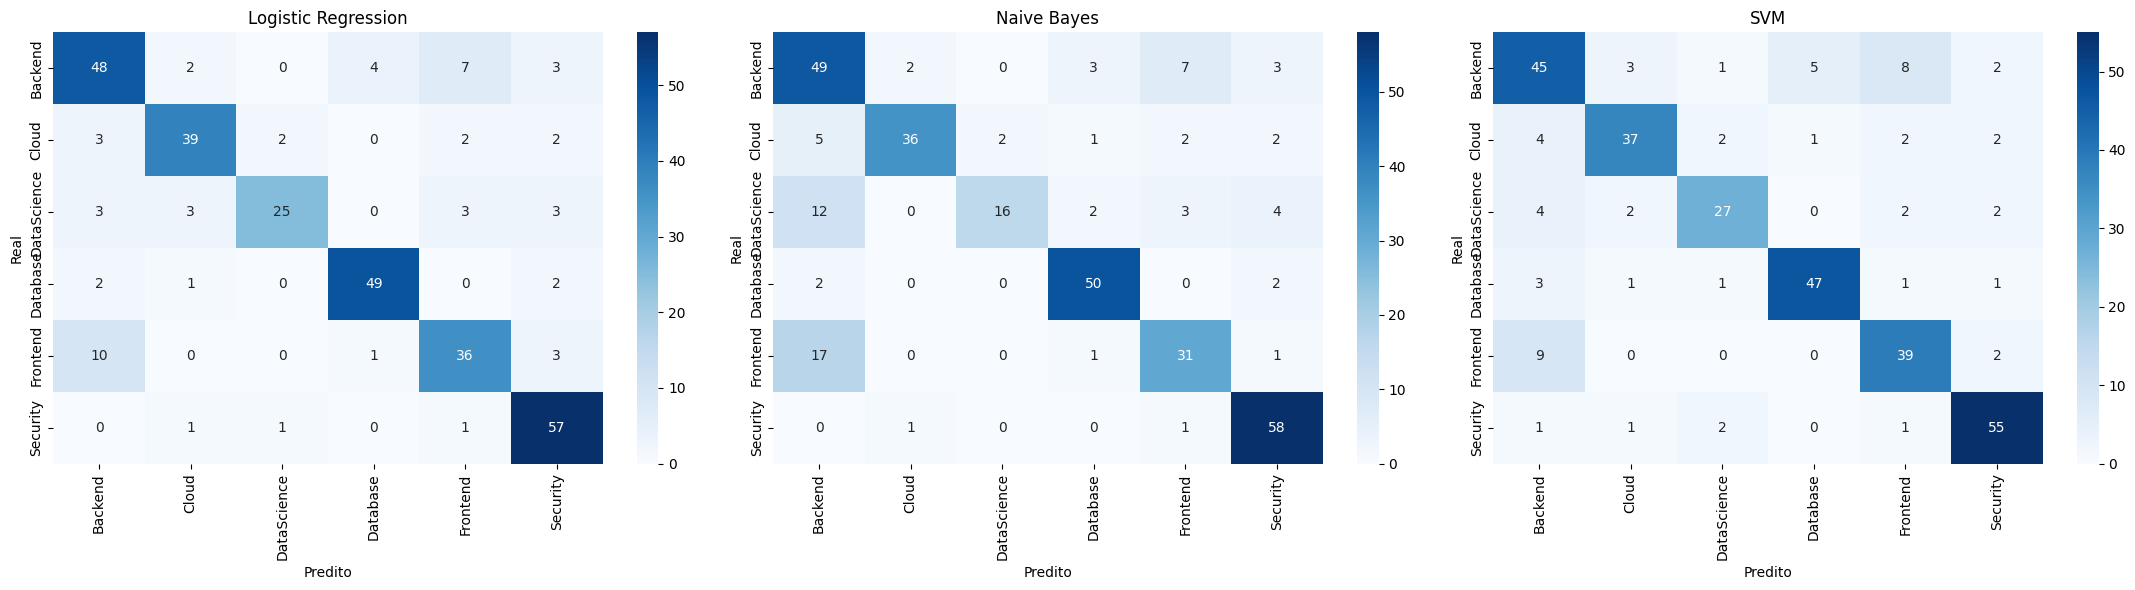

In [48]:
# Comparando as matrizes de confusão Logistic Regression vs. Naive Bayes vs. SVM
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=modelo_lr.classes_)
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=modelo_nb.classes_)
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=modelo_svm.classes_)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_lr.classes_, yticklabels=modelo_lr.classes_,
            ax=axes[0])
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')
axes[0].set_title('Logistic Regression')

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_nb.classes_, yticklabels=modelo_nb.classes_,
            ax=axes[1])
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_title('Naive Bayes')

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_svm.classes_, yticklabels=modelo_svm.classes_,
            ax=axes[2])
axes[2].set_xlabel('Predito')
axes[2].set_ylabel('Real')
axes[2].set_title('SVM')


plt.tight_layout()
plt.show()

A análise visual das matrizes de confusão confirma que os três modelos apresentam uma forte concentração de acertos na diagonal principal, demonstrando boa capacidade geral de distinção entre as seis categorias.

Destaques da Comparação

* **Classes com Maior Assertividade (`Security` e `Database`):**

   * `Security:` Apresentou excelente acerto em todos os modelos, liderado pelo Naive Bayes com 58 acertos, seguido pelo Logistic Regression (57) e SVM (55).

   * `Database:` Teve comportamento extremamente consistente, registrando 50 acertos no Naive Bayes, 49 no Logistic Regression e 47 no SVM, com pouquíssima confusão cruzada.

* **Principal Ponto de Confusão (`Backend` vs. `Frontend`):**

  * A maior sobreposição de erros ocorre bidirecionalmente entre as categorias de desenvolvimento:

     * No Logistic Regression, 10 chamados de `Frontend` foram previstos como `Backend`, e 7 de `Backend` como `Frontend.`

      * No SVM, 9 chamados de `Frontend` foram previstos como `Backend`, e 8 de `Backend` como `Frontend.`
   
      * No Naive Bayes, a confusão foi mais acentuada: 17 chamados de `Frontend` foram previstos como `Backend`, revelando uma atração desproporcional para a classe `Backend.`

  * Comportamento em `DataScience` e `Cloud:`

    * `DataScience` (Ponto Fraco do Naive Bayes): O Naive Bayes teve seu maior gargalo nessa classe, registrando apenas 16 acertos e prevendo 12 chamados erroneamente como `Backend.` O SVM liderou a categoria com 27 acertos, seguido de perto pelo modelo Logistic Regression com 25.

    * `Cloud:` Teve desempenho equivalente no modelo Logistic Regression (39 acertos) e no modelo SVM (37), com o Naive Bayes marcando 36 acertos.

Conclusão  
A comparação visual confirma que o modelo Logistic Regression e o modelo SVM mantêm um equilíbrio muito superior ao Naive Bayes. O modelo Logistic Regression se consolida como o modelo mais consistente, reduzindo drasticamente os falsos positivos em relação ao Naive Bayes e apresentando como único gargalo real a sobreposição semântica entre as áreas de `Backend` e `Frontend.`

## Extração de Palavras-Chave

A extração das palavras chave é realizada reaproveitando o mesmo vetor TF-IDF aplicado no treinamento do modelo. É possível extrair as palavras mais relevantes do texto, identificando os termos com maior peso (score TF-IDF) para aquele texto específico. Esses termos podem ser utilizados para facilitar buscas, organização e reutilização do conhecimento dentro da plataforma TechMind.

In [ ]:
def extrair_palavras_chave(texto, vectorizer, top_n=5):
    # Transforma o texto em vetor TF-IDF usando o vectorizer já treinado
    tfidf_vector = vectorizer.transform([texto])
    
    # Extrai os pesos TF-IDF do texto (matriz esparsa vira array simples de números)
    scores = tfidf_vector.toarray()[0]

    # Recupera os termos existentes no TF-IDF
    termos = vectorizer.get_feature_names_out()
    
    # Pega os índices dos termos com maior peso, em ordem decrescente
    top_indices = scores.argsort()[-top_n:][::-1]
    
    # Retorna as palavras ordenadas por relevância
    palavras_chave = [termos[i] for i in top_indices if scores[i] > 0]

    # Se quiser ver com o indice
    #palavras_chave = [(termos[i], round(scores[i], 3)) for i in top_indices if scores[i] > 0]
    
    return palavras_chave

In [ ]:
# Testando a extração de palavras-chave em alguns exemplos
resultados = []

for i in range(5):
    texto = X_test.iloc[i]
    categoria = y_test.iloc[i]
    palavras_chave = extrair_palavras_chave(texto, vectorizer, top_n=3)
    resultados.append({'categoria': categoria, 'palavras_chave': palavras_chave})

df_palavras_chave = pd.DataFrame(resultados)
df_palavras_chave

Testando a função de extração de palavras-chave em uma amostra do conjunto de teste, alguns resultados foram coerentes com a categoria real, como Cloud (container, azure, ngrok) e Database (ollama, ai, erd).

Ainda assim, é possível notar sobreposição de vocabulário entre categorias. O termo "ai" aparece tanto em exemplos de Backend quanto de Database, refletindo o quanto certas tecnologias (como IA e LLMs) permeiam múltiplas áreas técnicas. Isso é uma limitação esperada do TF-IDF, que identifica termos estatisticamente relevantes para o texto, mas não necessariamente exclusivos de uma única categoria.

## Estrutura do Retorno do Modelo Logistic Regression

O objetivo é preparar e simular a saída que será consumida pela API da aplicação, reunindo:

- Categoria prevista pelo modelo de classificação;
- Probabilidade associada à previsão;
- Palavras-chave extraídas do conteúdo analisado.

Esse teste considera os dados em memória

In [ ]:
# Função simulação 
def analisar_conteudo(texto):
    
    # Transformar texto para o formato do modelo
    texto_tfidf = vectorizer.transform([texto])
    
    # Categoria prevista
    categoria = modelo_lr.predict(texto_tfidf)[0]
    
    # Probabilidade da previsão
    probabilidades = modelo_lr.predict_proba(texto_tfidf)[0]
    probabilidade = float(probabilidades.max())
    
    # Palavras-chave
    palavras_chave = extrair_palavras_chave(
        texto,
        vectorizer,
        top_n=3
    )
    
    return {
        "categoria": str(categoria),
        "probabilidade": round(probabilidade, 2),
        "informacoes_adicionais": palavras_chave
    }

In [ ]:
# definindo texto teste
texto_teste = df_model.loc[0, 'texto']

In [ ]:
# Simulando o retorno
resultado = analisar_conteudo(texto_teste)
resultado

### Análise da Probabilidade de Classificação - Modelo Logistic Regression (Baseline)

In [ ]:
# Verificando todas as probabilidades do texto teste
probabilidades = modelo_lr.predict_proba(
    vectorizer.transform([texto_teste])
)[0]

df_prob = pd.DataFrame({
    'Categoria': modelo_lr.classes_,
    'Probabilidade': probabilidades
})

df_prob['Probabilidade'] = df_prob['Probabilidade'].round(4)

df_prob = df_prob.sort_values(
    by='Probabilidade',
    ascending=False
)

df_prob

O modelo retorna a distribuição de probabilidades entre todas as classes possíveis. Neste exemplo, a categoria `Security` apresentou a maior probabilidade de classificação (67,11%), enquanto as demais categorias apresentaram valores inferiores. Essa informação permite avaliar o nível de confiança associado à previsão realizada pelo modelo.

A probabilidade será utilizada como uma informação adicional no retorno da API, permitindo que aplicações consumidoras tenham visibilidade sobre o grau de confiança da classificação.

### Avaliação em Lote do Limiar(Threshold)- Prababilidade/Confiança - Modelo Logistic Regression (Baseline)

In [ ]:
def avaliar_threshold(modelo, X_test_tfidf, y_test, threshold=0.40):
    # 1. Obtém as probabilidades para todas as amostras de teste
    probabilidades = modelo.predict_proba(X_test_tfidf)
    
    # 2. Identifica a maior probabilidade e a classe predita correspondente para cada caso
    maiores_probs = probabilidades.max(axis=1)
    indices_preditos = probabilidades.argmax(axis=1)
    predicoes = modelo.classes_[indices_preditos]
    
    # 3. Aplica a regra do threshold
    aceitos_mask = maiores_probs >= threshold
    
    # Métricas gerais
    total_amostras = len(y_test)
    total_aceitos = aceitos_mask.sum()
    total_rejeitados = total_amostras - total_aceitos
    
    taxa_automacao = (total_aceitos / total_amostras) * 100
    taxa_transbordo = (total_rejeitados / total_amostras) * 100
    
    # Acurácia considerando apenas os casos onde a probabilidade foi >= threshold
    if total_aceitos > 0:
        acertos_aceitos = (predicoes[aceitos_mask] == np.array(y_test)[aceitos_mask]).sum()
        acuracia_filtrada = (acertos_aceitos / total_aceitos) * 100
    else:
        acuracia_filtrada = 0.0
        
    print(f"--- AVALIAÇÃO DE THRESHOLD: {threshold} ---")
    print(f"Total de Amostras de Teste: {total_amostras}")
    print(f"Classificados Automaticamente: {total_aceitos} ({taxa_automacao:.1f}%)")
    print(f"Enviados para Revisão/Indefinido: {total_rejeitados} ({taxa_transbordo:.1f}%)")
    print(f"Acurácia nos Automáticos: {acuracia_filtrada:.1f}%\n")

In [ ]:
for t in [0.40, 0.50, 0.55, 0.60, 0.70]:
    avaliar_threshold(modelo_lr, X_test_tfidf, y_test, threshold=t)

In [ ]:
# limiar de 0.40 (Melhor desempenho)
print("--- AVALIAÇÂO RECOMENDADA ---")
avaliar_threshold(modelo_lr, X_test_tfidf, y_test, threshold=0.40)

A combinação do modelo Logistic Regression (Baseline) com o threshold de 0.40 atinge 65,2% de automação e 89,7% de acurácia nas previsões diretas, retendo 34,8% das requisições na categoria genérica por não atingirem o limite mínimo de probabilidade.

## Estrutura do Retorno do Modelo SVM (Baseline)

O objetivo é preparar e simular a saída que será consumida pela API da aplicação, reunindo:

- Categoria prevista pelo modelo de classificação;
- Probabilidade associada à previsão;
- Palavras-chave extraídas do conteúdo analisado.

Esse teste considera os dados em memória

In [ ]:
# Função simulação 
def analisar_conteudo(texto):
    
    # Transformar texto para o formato do modelo
    texto_tfidf = vectorizer.transform([texto])
    
    # Categoria prevista
    categoria = modelo_svm.predict(texto_tfidf)[0]
    
    # Probabilidade da previsão
    probabilidades = modelo_svm.predict_proba(texto_tfidf)[0]
    probabilidade = float(probabilidades.max())
    
    # Palavras-chave
    palavras_chave = extrair_palavras_chave(
        texto,
        vectorizer,
        top_n=3
    )
    
    return {
        "categoria": str(categoria),
        "probabilidade": round(probabilidade, 2),
        "informacoes_adicionais": palavras_chave
    }

In [ ]:
# definindo texto teste
texto_teste = df_model['texto'].iloc[0]

In [ ]:
# Simulando o retorno
resultado = analisar_conteudo(texto_teste)
resultado

### Análise da Probabilidade de Classificação SVM (Baseline)

In [ ]:
# Verificando todas as probabilidades do texto teste
probabilidades = modelo_svm.predict_proba(
    vectorizer.transform([texto_teste])
)[0]

df_prob = pd.DataFrame({
    'Categoria': modelo_svm.classes_,
    'Probabilidade': probabilidades
})

df_prob['Probabilidade'] = df_prob['Probabilidade'].round(4)

df_prob = df_prob.sort_values(
    by='Probabilidade',
    ascending=False
)

df_prob

O modelo retorna a distribuição de probabilidades entre todas as classes possíveis. Neste exemplo, a categoria `Security` apresentou a maior probabilidade de classificação (99%), enquanto as demais categorias apresentaram valores inferiores. Essa informação permite avaliar o nível de confiança associado à previsão realizada pelo modelo.

A probabilidade será utilizada como uma informação adicional no retorno da API, permitindo que aplicações consumidoras tenham visibilidade sobre o grau de confiança da classificação.

### Avaliação em Lote do Limiar(Threshold)- Prababilidade/Confiança - Modelo SVM (Baseline)

In [ ]:
for t in [0.40, 0.50, 0.55, 0.60, 0.70]:
    avaliar_threshold(modelo_svm, X_test_tfidf, y_test, threshold=t)

In [ ]:
# limiar de 0.40 (Melhor desempenho)
print("--- AVALIAÇÂO RECOMENDADA ---")
avaliar_threshold(modelo_svm, X_test_tfidf, y_test, threshold=0.70)

A combinação do modelo SVM (Baseline) com o threshold de 0.70 atinge 72,5% de automação e 89,4% de acurácia nas previsões diretas, retendo 27,5% das requisições na categoria genérica por não atingirem o limite mínimo de probabilidade.

## Serialização do Modelo Logistic Regression (Baseline)

A serialização permite salvar o modelo treinado e o vetor TF-IDF em arquivo persistente, possibilitando que a aplicação Back-End carregue esses componentes sem a necessidade de realizar novamente o treinamento.

Serão armazenados:

- Modelo de classificação (`modelo_lr`);
- Vetorizador TF-IDF (`vectorizer`).

O arquivo .pkl armazendo será utilizado posteriormente pela API da aplicação Techmind para realizar novas classificações de conteúdos técnicos, juntamente com a extração das palavras-chave e geração das informações de retorno.

In [ ]:
# Gerando arquivo .pkl
artefatos_modelo = {
    "modelo": modelo_lr,
    "vectorizer": vectorizer
}

joblib.dump(
    artefatos_modelo,
    '../modelo/modelo_techmind.pkl'
)

## Exemplos de Uso (JSON) - Modelo Logistic Regression (Baseline)

Nesta etapa será simulada a utilização do modelo em um cenário próximo ao funcionamento da API.

Serão enviados exemplos de conteúdos técnicos como entrada, representando requisições realizadas por usuários. O modelo realizará a classificação do conteúdo, calculará a probabilidade da previsão e retornará as palavras-chave identificadas.

A saída será estruturada em formato JSON, seguindo o padrão esperado para integração com a aplicação Backend.

In [ ]:
# Simula o consumo o arquivo .pkl
artefatos = joblib.load('../modelo/modelo_techmind.pkl')

modelo = artefatos["modelo"]
vectorizer = artefatos["vectorizer"]

In [ ]:
# Confirma que os artefatos foram carregados corretamente a partir do .pkl
type(modelo), type(vectorizer)

In [ ]:
# Texto Teste
textos_teste = (
    df_model['texto']
    .sample(3, random_state=42)
    .tolist()
)

textos_teste

In [ ]:
def analisar_conteudo_api(texto, modelo, vectorizer):
    
    texto_tfidf = vectorizer.transform([texto])
    
    categoria = modelo.predict(texto_tfidf)[0]
    
    probabilidade = modelo.predict_proba(texto_tfidf).max()
    
    palavras_chave = extrair_palavras_chave(
        texto,
        vectorizer,
        top_n=3
    )
    
    return {
        "categoria": str(categoria),
        "probabilidade": float(probabilidade),
        "informacoes_adicionais": palavras_chave
    }

In [ ]:
# Simulando resultado
resultados_json = []

for texto in textos_teste:
    
    resultado = analisar_conteudo_api(
        texto,
        modelo,
        vectorizer
    )
    
    resultados_json.append(resultado)


print(json.dumps(resultados_json, indent=4, ensure_ascii=False))

Os resultados demonstram que o modelo conseguiu gerar as previsões utilizando os artefatos carregados a partir do arquivo `.pkl`, mantendo a integração entre o modelo de classificação e o vetor TF-IDF utilizado no treinamento. 

As probabilidades retornadas indicam o nível de confiança da classificação para cada conteúdo analisado, enquanto as palavras-chave destacam os termos mais relevantes identificados na representação vetorial do texto.

Nos três exemplos testados, o modelo classificou corretamente os temas centrais dos textos: Database (75,6% de confiança, com palavras-chave table, relationship, join), Security (48,2%, com address, ipv, privacy) e Frontend (29%, com gate, fan, app). O terceiro caso, com probabilidade mais baixa, mostra um texto de classificação mais incerta, situação esperada em conteúdos que abordam temas com vocabulário menos exclusivo de uma única categoria.

O retorno já está no formato JSON esperado pela API, pronto para ser consumido pelo backend.

## Serialização do Modelo SVM (Baseline)

A serialização permite salvar o modelo treinado e o vetor TF-IDF em arquivo persistente, possibilitando que a aplicação Back-End carregue esses componentes sem a necessidade de realizar novamente o treinamento.

Serão armazenados:

- Modelo de classificação (`modelo_svm`);
- Vetorizador TF-IDF (`vectorizer`).

O arquivo .pkl armazendo será utilizado posteriormente pela API da aplicação Techmind para realizar novas classificações de conteúdos técnicos, juntamente com a extração das palavras-chave e geração das informações de retorno.

### Arquivo .pkl

In [ ]:
# Gerando arquivo .pkl
artefatos_modelo = {
    "modelo": modelo_svm,
    "vectorizer": vectorizer
}

joblib.dump(
    artefatos_modelo,
    '../modelo/modelo_svm.pkl'
)

### Arquivo .joblib

In [ ]:
# Gerando arquivo .joblib
artefatos_modelo = {
    "modelo": modelo_svm,
    "vectorizer": vectorizer
}

joblib.dump(
    artefatos_modelo,
    '../modelo/modelo_svm.joblib'
)

### Métricas de comparação pickle vs joblib

In [ ]:
import os
import time
import pickle
import joblib

# 1. Definir os caminhos dos arquivos
caminho_pkl = '../modelo/modelo_svm.pkl'
caminho_joblib = '../modelo/modelo_svm.joblib'

# Dicionário com seus artefatos (modelo + vetorizador)
artefatos_modelo = {
    "modelo": modelo_svm_balanced,
    "vectorizer": vectorizer
}

# --- TESTE 1: PICKLE ---
# Tempo de Escrita (Dump)
inicio = time.perf_counter()
with open(caminho_pkl, 'wb') as f:
    pickle.dump(artefatos_modelo, f)
tempo_escrita_pkl = time.perf_counter() - inicio

# Tempo de Leitura (Load)
inicio = time.perf_counter()
with open(caminho_pkl, 'rb') as f:
    _ = pickle.load(f)
tempo_leitura_pkl = time.perf_counter() - inicio

# Tamanho do Arquivo em MB
tamanho_pkl = os.path.getsize(caminho_pkl) / (1024 * 1024)


# --- TESTE 2: JOBLIB ---
# Tempo de Escrita (Dump)
inicio = time.perf_counter()
joblib.dump(artefatos_modelo, caminho_joblib)
tempo_escrita_joblib = time.perf_counter() - inicio

# Tempo de Leitura (Load)
inicio = time.perf_counter()
_ = joblib.load(caminho_joblib)
tempo_leitura_joblib = time.perf_counter() - inicio

# Tamanho do Arquivo em MB
tamanho_joblib = os.path.getsize(caminho_joblib) / (1024 * 1024)


# --- EXIBIÇÃO DA MÉTRICA DE COMPARAÇÃO ---
print(f"{'Métrica':<25} | {'Pickle (.pkl)':<15} | {'Joblib (.joblib)':<15}")
print("-" * 60)
print(f"{'Tamanho do Arquivo (MB)':<25} | {tamanho_pkl:<15.2f} | {tamanho_joblib:<15.2f}")
print(f"{'Tempo de Escrita (s)':<25} | {tempo_escrita_pkl:<15.4f} | {tempo_escrita_joblib:<15.4f}")
print(f"{'Tempo de Leitura (s)':<25} | {tempo_leitura_pkl:<15.4f} | {tempo_leitura_joblib:<15.4f}")

## Exemplos de Uso (JSON) - Modelo SVM (Baseline)

In [ ]:
# Simula o consumo o arquivo .pkl
artefatos = joblib.load('../modelo/modelo_svm.pkl')

modelo = artefatos["modelo"]
vectorizer = artefatos["vectorizer"]

In [ ]:
# Confirma que os artefatos foram carregados corretamente a partir do .pkl
type(modelo), type(vectorizer)

In [ ]:
# Texto Teste
textos_teste = (
    df_model['texto']
    .sample(3, random_state=42)
    .tolist()
)

textos_teste

In [ ]:
def analisar_conteudo_api(texto, modelo, vectorizer):
    
    texto_tfidf = vectorizer.transform([texto])
    
    categoria = modelo.predict(texto_tfidf)[0]
    
    probabilidade = modelo.predict_proba(texto_tfidf).max()
    
    palavras_chave = extrair_palavras_chave(
        texto,
        vectorizer,
        top_n=3
    )
    
    return {
        "categoria": str(categoria),
        "probabilidade": float(probabilidade),
        "informacoes_adicionais": palavras_chave
    }

In [ ]:
# Simulando resultado
resultados_json = []

for texto in textos_teste:
    
    resultado = analisar_conteudo_api(
        texto,
        modelo,
        vectorizer
    )
    
    resultados_json.append(resultado)


print(json.dumps(resultados_json, indent=4, ensure_ascii=False))

Os resultados demonstram que o modelo conseguiu gerar as previsões utilizando os artefatos carregados a partir do arquivo `.pkl`, mantendo a integração entre o modelo de classificação e o vetor TF-IDF utilizado no treinamento. 

As probabilidades retornadas indicam o nível de confiança da classificação para cada conteúdo analisado, enquanto as palavras-chave destacam os termos mais relevantes identificados na representação vetorial do texto.

Nos três exemplos testados, o modelo classificou corretamente os temas centrais dos textos: `Database` (98,9% de confiança, com palavras-chave table, relationship, join), `Security` (98,5%, com address, ipv, privacy) e `Frontend` (87,9%, com gate, fan, app). O terceiro caso, com probabilidade mais baixa, mostra um texto de classificação mais incerta, situação esperada em conteúdos que abordam temas com vocabulário menos exclusivo de uma única categoria.

O retorno já está no formato JSON esperado pela API, pronto para ser consumido pelo backend.

## Conclusões

In [ ]:
# PENDENTE DEMAIS MODELOS 